# Part 2 — Measuring Σ<sub>sub</sub> from the subhalo population

In [Part 1](01-setup-and-run.md) you ran a Galacticus model of a
10<sup>13</sup> M<sub>☉</sub> host halo at *z* = 0.5 and its population of dark
matter subhalos. This notebook analyses that output with
[Dendros](https://dendros.readthedocs.io/) to:

1. read the subhalo properties,
2. measure the **projected subhalo number density, Σ<sub>sub</sub>**, the
   quantity used as a dark-matter probe in strong-lensing studies
   ([Gilman et al. 2020](https://ui.adsabs.harvard.edu/abs/2020MNRAS.491.6077G)),
3. recover the subhalo mass-function slope, and
4. make an **interactive 3D visualisation** of the subhalos orbiting the host.

> **What is Σ<sub>sub</sub>?** Gilman et al. write the projected subhalo mass
> function as
> $$\frac{d^2 N_{\rm sub}}{dm\,dA} = \frac{\Sigma_{\rm sub}}{m_0}\left(\frac{m}{m_0}\right)^{-\alpha},\qquad m_0 = 10^8\,M_\odot .$$
> So Σ<sub>sub</sub> (units: kpc<sup>−2</sup>) is the *amplitude* of the projected
> subhalo mass function at the pivot mass 10<sup>8</sup> M<sub>☉</sub>. We will
> measure it directly by counting subhalos.


## 1. Load the model output

The cell below finds your output file. If you ran the model yourself in Part 1,
it uses **your** `subhalos_1e13_z0.5.hdf5`. If that isn't there yet (or your run
is still going), it falls back to the precomputed copy shipped in
`tutorial/data/`, so you can keep working either way.

In [1]:
from pathlib import Path
from dendros import open_outputs

# Look for your own run first, then the shipped fallback. The live run lands in
# whatever directory you launched `galacticus run` from (usually the repo root).
candidates = [
    "subhalos_1e13_z0.5.hdf5",
    "../subhalos_1e13_z0.5.hdf5",
    "tutorial/data/subhalos_1e13_z0.5.hdf5",
    "../tutorial/data/subhalos_1e13_z0.5.hdf5",
    "data/subhalos_1e13_z0.5.hdf5",
]
path = next((p for p in candidates if Path(p).exists()), None)
assert path, "Could not find the output file. Run Part 1, or check tutorial/data/."
print("Using:", path)
if "tutorial/data" in path or "data/" in path:
    print("  (this is the shipped precomputed copy — that's fine!)")

c = open_outputs(path)
c.validate_completion()   # raises if any tree failed to finish; silent = all good

Using: ../tutorial/data/subhalos_1e13_z0.5.hdf5
  (this is the shipped precomputed copy — that's fine!)


## 2. What's in the file?

Dendros gives us a friendly view of the output. `list_outputs()` shows the
snapshots (we asked for just one, at *z* = 0.5); `list_properties()` lists every
per-node dataset with its units.

In [2]:
c.list_outputs()

index,name,time,scale_factor,redshift,output_type
int64,str7,float64,float64,float64,str8
1,Output1,8.588010518508764,0.6666666666666666,0.5,snapshot


In [3]:
props = c.list_properties("Output1")
print(f"{len(props)} properties available. A few we'll use:")
props[[n in ("nodeIsIsolated", "basicMass", "satelliteBoundMass",
             "positionOrbitalX", "positionOrbitalY", "positionOrbitalZ",
             "darkMatterOnlyRadiusVirial", "mergerTreeIndex") for n in props["name"]]]

41 properties available. A few we'll use:


name,dtype,shape,description,units
str41,str7,str10,str129,str13
basicMass,float64,"(70771,)","Total mass of the node, assuming universal baryon fraction.",Solar masses
darkMatterOnlyRadiusVirial,float64,"(70771,)",Virial radius of the dark matter only node [Mpc].,Mpc
mergerTreeIndex,int64,"(70771,)",Tree index for this node.,
nodeIsIsolated,int64,"(70771,)",Is the node isolated (0|1)?,
positionOrbitalX,float64,"(70771,)",The orbital x-position of the halo relative to the top-level host halo (i.e. the host which is not a sub-halo of any other halo).,Mpc
positionOrbitalY,float64,"(70771,)",The orbital y-position of the halo relative to the top-level host halo (i.e. the host which is not a sub-halo of any other halo).,Mpc
positionOrbitalZ,float64,"(70771,)",The orbital z-position of the halo relative to the top-level host halo (i.e. the host which is not a sub-halo of any other halo).,Mpc
satelliteBoundMass,float64,"(70771,)",Bound mass of the node.,Solar masses


## 3. Read the subhalo properties

Each row of `nodeData` is a halo. The key fields:

| Dataset | Meaning |
| --- | --- |
| `nodeIsIsolated` | 1 = host (central), 0 = **subhalo** |
| `basicMass` | mass at infall (when it was last an isolated halo) |
| `satelliteBoundMass` | **current** bound mass, after tidal stripping |
| `positionOrbitalX/Y/Z` | position relative to the host centre (Mpc) |
| `darkMatterOnlyRadiusVirial` | virial radius |
| `mergerTreeIndex` | which of our 16 host realisations this node belongs to |

Datasets come back as [astropy quantities](https://docs.astropy.org/en/stable/units/)
with units attached, so we convert explicitly to the units we want.

In [4]:
import numpy as np

d = c.read("Output1", [
    "nodeData/nodeIsIsolated",
    "nodeData/basicMass",
    "nodeData/satelliteBoundMass",
    "nodeData/positionOrbitalX",
    "nodeData/positionOrbitalY",
    "nodeData/positionOrbitalZ",
    "nodeData/darkMatterOnlyRadiusVirial",
    "nodeData/mergerTreeIndex",
])

is_isolated = d["nodeData/nodeIsIsolated"].astype(int)
m_bound     = d["nodeData/satelliteBoundMass"].to("Msun").value
m_infall    = d["nodeData/basicMass"].to("Msun").value
x = d["nodeData/positionOrbitalX"].to("kpc").value
y = d["nodeData/positionOrbitalY"].to("kpc").value
z = d["nodeData/positionOrbitalZ"].to("kpc").value
r_vir = d["nodeData/darkMatterOnlyRadiusVirial"].to("kpc").value
tree  = d["nodeData/mergerTreeIndex"].astype(int)

is_sub = is_isolated == 0
is_host = is_isolated == 1
n_trees = int(is_host.sum())

Rvir_host = float(np.median(r_vir[is_host]))       # host virial radius (kpc)
print(f"{n_trees} host realisations, {is_sub.sum()} subhalos in total")
print(f"host virial radius R_vir = {Rvir_host:.0f} kpc")
print(f"subhalo current bound masses span {m_bound[is_sub].min():.1e} - {m_bound[is_sub].max():.1e} Msun")

16 host realisations, 70755 subhalos in total
host virial radius R_vir = 428 kpc
subhalo current bound masses span 3.0e+07 - 3.5e+12 Msun


## 4. The subhalo mass function and its slope

Before measuring Σ<sub>sub</sub>, let's look at the projected subhalo mass
function itself — the number of subhalos per unit mass per unit projected area,
averaged over our host realisations. Gilman et al. assume a power law with slope
α ≈ 1.9; let's see what Galacticus gives.

We project the 3D positions onto a plane (here the *x–y* plane, i.e. viewing
along *z*) and use the **current bound mass**.

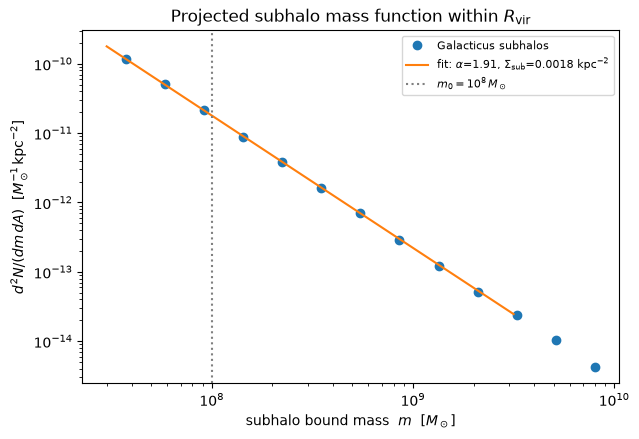

Recovered slope alpha = 1.91   (Gilman et al. assume ~1.9)


In [5]:
import matplotlib.pyplot as plt

R_proj = np.sqrt(x**2 + y**2)                 # projected radius (kpc)
area_vir = np.pi * Rvir_host**2               # projected area within R_vir (kpc^2)

# Subhalos within the projected virial radius
sel = is_sub & (R_proj < Rvir_host)

m0 = 1.0e8                                     # pivot mass (Msun)
edges = np.logspace(np.log10(3e7), 10, 14)    # from the resolution up to ~1e10
centre = np.sqrt(edges[:-1] * edges[1:])
width  = np.diff(edges)

counts, _ = np.histogram(m_bound[sel], bins=edges)
dN_dm_dA  = counts / (n_trees * width * area_vir)   # per host, per Msun, per kpc^2

# Power-law fit where we have enough counts
ok = counts > 10
G = np.vstack([np.ones(ok.sum()), np.log(centre[ok] / m0)]).T
(logA, slope), *_ = np.linalg.lstsq(G, np.log(dN_dm_dA[ok]), rcond=None)
alpha = -slope
Sigma_from_fit = m0 * np.exp(logA)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(centre[ok], dN_dm_dA[ok], "o", label="Galacticus subhalos")
mm = np.logspace(np.log10(3e7), 9.5, 50)
ax.loglog(mm, (Sigma_from_fit/m0) * (mm/m0)**(-alpha), "-",
          label=fr"fit: $\alpha$={alpha:.2f}, $\Sigma_{{\rm sub}}$={Sigma_from_fit:.4f} kpc$^{{-2}}$")
ax.axvline(m0, color="grey", ls=":", label=r"$m_0 = 10^8\,M_\odot$")
ax.set_xlabel(r"subhalo bound mass  $m$  [$M_\odot$]")
ax.set_ylabel(r"$d^2N/(dm\,dA)$  [$M_\odot^{-1}\,{\rm kpc}^{-2}$]")
ax.set_title(r"Projected subhalo mass function within $R_{\rm vir}$")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Recovered slope alpha = {alpha:.2f}   (Gilman et al. assume ~1.9)")

## 5. Measure Σ<sub>sub</sub>

Now the headline number. We measure Σ<sub>sub</sub> directly as

$$\Sigma_{\rm sub} = m_0 \left.\frac{d^2N}{dm\,dA}\right|_{m=m_0},$$

by counting subhalos in a half-decade mass bin centred on 10<sup>8</sup> M<sub>☉</sub>
that fall within a projected aperture, then dividing by (bin width × area), and
averaging over our host realisations.

**Σ<sub>sub</sub> is not a single number — it depends on where you look.** The
subhalos are more concentrated toward the halo centre, so the projected density
is higher there. Strong lensing probes the region near the Einstein radius
(tens of kpc from the centre), where Σ<sub>sub</sub> is larger than the
halo-wide average. We compute it in a few apertures to show this.

In [6]:
m_lo, m_hi = 10**7.75, 10**8.25       # half-decade bin around m0 = 1e8
dm = m_hi - m_lo

def sigma_sub(R_aperture_kpc):
    """Sigma_sub within a projected aperture, as mean +/- std over host realisations."""
    area = np.pi * R_aperture_kpc**2
    in_bin = is_sub & (m_bound >= m_lo) & (m_bound < m_hi) & (R_proj < R_aperture_kpc)
    per_tree = np.array([
        m0 * np.count_nonzero(in_bin & (tree == t)) / (dm * area)
        for t in np.unique(tree[is_host])
    ])
    return per_tree.mean(), per_tree.std()

print(f"{'aperture':>22}   {'R (kpc)':>8}   Sigma_sub [kpc^-2]")
print("-" * 60)
for label, frac in [("within R_vir", 1.0),
                    ("within 0.5 R_vir", 0.5),
                    ("within 0.1 R_vir (~lensing)", 0.1)]:
    R_ap = frac * Rvir_host
    mean, std = sigma_sub(R_ap)
    print(f"{label:>22}   {R_ap:8.1f}   {mean:.4f} +/- {std:.4f}")

              aperture    R (kpc)   Sigma_sub [kpc^-2]
------------------------------------------------------------
          within R_vir      428.1   0.0018 +/- 0.0001
      within 0.5 R_vir      214.0   0.0038 +/- 0.0005
within 0.1 R_vir (~lensing)       42.8   0.0073 +/- 0.0017


So Galacticus predicts, for this 10<sup>13</sup> M<sub>☉</sub> host at
*z* = 0.5, a halo-averaged Σ<sub>sub</sub> of a few × 10<sup>−3</sup> kpc<sup>−2</sup>,
rising toward the centre. These are in the ballpark of the values Gilman et al.
infer from quasar-lens flux-ratio anomalies — the connection between a
semi-analytic subhalo population and a real dark-matter measurement.

> **Caveats worth stating in the tutorial.** This is a deliberately simplified
> measurement: a single host mass, one projection axis, a bound-mass definition,
> and a circular aperture centred on the halo. Real lensing measurements average
> over a specific projected region set by the lens geometry, marginalise over
> host properties, and must model line-of-sight halos too. The point here is to
> see *where the number comes from*.

## 6. Interactive 3D view of the subhalo population

Finally, let's *see* the subhalos. The plot below is fully interactive — drag to
rotate, scroll to zoom. Each point is a subhalo, coloured by its current bound
mass; the translucent sphere marks the host virial radius. Point size scales
with mass.

In [7]:
import plotly.graph_objects as go

# One host realisation makes the clearest picture; change to see others.
which_tree = np.unique(tree[is_host])[0]
sel3d = is_sub & (tree == which_tree)

xs, ys, zs = x[sel3d], y[sel3d], z[sel3d]
ms = m_bound[sel3d]
logm = np.log10(ms)

# Translucent host virial sphere
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
sx = Rvir_host * np.cos(u) * np.sin(v)
sy = Rvir_host * np.sin(u) * np.sin(v)
sz = Rvir_host * np.cos(v)

fig = go.Figure()
fig.add_trace(go.Surface(x=sx, y=sy, z=sz, opacity=0.12, showscale=False,
                         colorscale=[[0, "gray"], [1, "gray"]], hoverinfo="skip",
                         name="host R_vir"))
fig.add_trace(go.Scatter3d(
    x=xs, y=ys, z=zs, mode="markers",
    marker=dict(size=2 + 4*(logm - logm.min())/(np.ptp(logm) + 1e-9),
                color=logm, colorscale="Viridis", opacity=0.8,
                colorbar=dict(title="log₁₀ m<sub>bound</sub><br>[M<sub>☉</sub>]")),
    text=[f"m_bound = {m:.2e} Msun" for m in ms],
    hovertemplate="%{text}<extra></extra>", name="subhalos"))
fig.update_layout(
    title=f"Subhalos orbiting a 10¹³ M☉ host at z=0.5  (realisation {which_tree}, "
          f"{sel3d.sum()} subhalos)",
    scene=dict(xaxis_title="x [kpc]", yaxis_title="y [kpc]", zaxis_title="z [kpc]",
               aspectmode="data"),
    width=760, height=640, margin=dict(l=0, r=0, t=40, b=0))
fig.show()

## Where to go next

- **Change the projection or aperture** in §5 and watch Σ<sub>sub</sub> respond.
- **Use infall mass** (`m_infall`) instead of bound mass and compare — the choice
  of mass definition matters for how Σ<sub>sub</sub> is defined.
- **CDM vs. warm dark matter.** Σ<sub>sub</sub> is precisely the quantity Gilman
  et al. use to constrain WDM: a warmer particle suppresses low-mass subhalos and
  lowers Σ<sub>sub</sub>. Re-run Part 1 with a WDM transfer function and see the
  suppression. (See `tutorial/INSTRUCTOR_NOTES.md` and
  [`docs/references.md`](../docs/references.md).)
- **Vary the host mass or redshift** in the parameter file and see how the
  subhalo population changes.

You've now run a galaxy/dark-matter formation model, analysed its output, and
connected it to a real observational dark-matter probe. 🎉